# DATA 608 - Probality & Statistics
## PHYSICAL FITNESS PREDICTION PROJECT
------------------------------------------------------------------------------------------------------------------------------------------------------------

**Instructor : Prof. Zeynep Kacar**

**Team Members : Soumya Bhate | Hari Krishnan Sudheendran**

------------------------------------------------------------------------------------------------------------------------------------------------------------

**Predicting Physical Fitness through Lifestyle Factors**

In an era of increasing sedentary behavior, understanding the lifestyle determinants of physical health has never been more critical. This project utilizes data from the National Health and Nutrition Examination Survey (NHANES) to investigate how daily habits—specifically sleep patterns, activity levels, and sedentary time—interact with demographic factors to influence an individual’s overall physical fitness. By defining fitness through the lens of healthy BMI and active lifestyle markers, this study seeks to identify which health indicators are most predictive of physical wellness. Our goal is to provide data-driven insights that can help inform personal health decisions and public wellness recommendations.

------------------------------------------------------------------------------------------------------------------------------------------------------------

## I. Dataset Background

**1. Source -** 
The dataset used in this project is derived from the National Health and Nutrition Examination Survey (NHANES), conducted by the Centers for Disease Control and Prevention. NHANES is a nationally representative survey program that collects health and nutrition data from individuals across the United States through interviews, physical examinations, and laboratory tests. The dataset corresponds to the 2017–2020 cycle and is publicly available through the CDC website.

**2. Purpose -**
The primary purpose of this dataset is to assess the health and nutritional status of adults and children in the United States. It is widely used for:

- Public health research
- Policy-making and healthcare planning
- Understanding relationships between lifestyle, nutrition, and disease

In this project, the dataset is used to analyze how lifestyle and health factors influence physical fitness levels.

**3. Context -**
This dataset includes a combination of:

- Demographic variables (e.g., age, gender, education)
- Lifestyle factors (e.g., sleep duration, physical activity, daily steps)
- Health indicators (e.g., BMI, heart rate, stress/depression levels)

According to the project definition , an individual is considered “physically fit” if they:

- Belong to the Normal BMI category, and
- Have a physical activity level above the dataset median

This allows us to convert the problem into a binary classification task, suitable for logistic regression.

**4. Variable Description -**

*Numerical Variables*

- Age: Age of the individual (in years)
- Sleep Duration: Average hours of sleep per night
- Physical Activity Level: Daily activity score (scale 0–100)
- Depression Level: Self-reported depression level (scale 1–10)
- Heart Rate: Resting heart rate (beats per minute)
- Daily Steps: Average number of steps per day
- Height: Height (in centimeters)
- Weight: Weight (in kilograms)

*Categorical Variables*

- Gender: Male or Female
- BMI Category: Underweight, Normal, Overweight, Obese
- Education: Education level of the individual
- Sleep Disorder: None, Insomnia, or Sleep Apnea

**5. Measurement Types -**

- Numerical Variables: Continuous or discrete quantitative values (e.g., age, steps, heart rate)
- Categorical Variables: Qualitative group labels (e.g., gender, BMI category)

**6. Why This Dataset is Suitable -**
This dataset is appropriate for the project because:

- It contains both numerical and categorical variables, enabling diverse analysis techniques
- It has sufficient observations (≈1028)
- It directly supports the research question on physical fitness prediction
- It aligns well with statistical methods such as ANOVA and logistic regression

------------------------------------------------------------------------------------------------------------------------------------------------------------

## II. Merging & Cleaning Dataset

### 1. Loading all the files

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
# Load all NHANES files
demo = pd.read_sas("Datasets/P_DEMO.xpt", format="xport")
slq = pd.read_sas("Datasets/P_SLQ.xpt", format="xport")
paq = pd.read_sas("Datasets/P_PAQ.xpt", format="xport")
diq = pd.read_sas("Datasets/P_DIQ.xpt", format="xport")
cdq = pd.read_sas("Datasets/P_CDQ.xpt", format="xport")
whq = pd.read_sas("Datasets/P_WHQ.xpt", format="xport")

# Print shapes
print("DEMO shape:", demo.shape)
print("SLQ shape:", slq.shape)
print("PAQ shape:", paq.shape)
print("DIQ shape:", diq.shape)
print("CDQ shape:", cdq.shape)
print("WHQ shape:", whq.shape)

DEMO shape: (15560, 29)
SLQ shape: (10195, 11)
PAQ shape: (9693, 17)
DIQ shape: (14986, 28)
CDQ shape: (6433, 17)
WHQ shape: (10195, 35)


### 2. Checking columns in each file

In [71]:
print("\nDEMO columns:")
print(demo.columns.tolist())

print("\nSLQ columns:")
print(slq.columns.tolist())

print("\nPAQ columns:")
print(paq.columns.tolist())

print("\nDIQ columns:")
print(diq.columns.tolist())

print("\nCDQ columns:")
print(cdq.columns.tolist())

print("\nWHQ columns:")
print(whq.columns.tolist())


DEMO columns:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDYRUSZ', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'WTINTPRP', 'WTMECPRP', 'SDMVPSU', 'SDMVSTRA', 'INDFMPIR']

SLQ columns:
['SEQN', 'SLQ300', 'SLQ310', 'SLD012', 'SLQ320', 'SLQ330', 'SLD013', 'SLQ030', 'SLQ040', 'SLQ050', 'SLQ120']

PAQ columns:
['SEQN', 'PAQ605', 'PAQ610', 'PAD615', 'PAQ620', 'PAQ625', 'PAD630', 'PAQ635', 'PAQ640', 'PAD645', 'PAQ650', 'PAQ655', 'PAD660', 'PAQ665', 'PAQ670', 'PAD675', 'PAD680']

DIQ columns:
['SEQN', 'DIQ010', 'DID040', 'DIQ160', 'DIQ180', 'DIQ050', 'DID060', 'DIQ060U', 'DIQ070', 'DIQ230', 'DIQ240', 'DID250', 'DID260', 'DIQ260U', 'DIQ275', 'DIQ280', 'DIQ291', 'DIQ300S', 'DIQ300D', 'DID310S', 'DID310D', 'DID320', 'DID330', 'DID341', 'DID350', 'DIQ350U', 'DIQ360', 'DIQ080']

CDQ columns:
['SEQN', 'CDQ001', 'CDQ0

### 3. Build smaller datasets before merging

In [72]:
# Select useful columns only
demo_small = demo[["SEQN", "RIDAGEYR", "RIAGENDR", "DMDEDUC2"]]

slq_small = slq[["SEQN", "SLD012", "SLD013"]]

paq_small = paq[["SEQN", "PAD615", "PAD630", "PAD680"]]

whq_small = whq[["SEQN", "WHD010", "WHD020"]]

# Optional files
diq_small = diq[["SEQN", "DIQ010"]]
cdq_small = cdq[["SEQN"]]

### 4. Merge all selected files

In [73]:
# Merge datasets
df = demo_small.merge(slq_small, on="SEQN", how="inner") \
               .merge(paq_small, on="SEQN", how="inner") \
               .merge(whq_small, on="SEQN", how="inner") \
               .merge(diq_small, on="SEQN", how="left")

print("Merged shape:", df.shape)
print(df.head())

Merged shape: (9693, 12)
       SEQN  RIDAGEYR  RIAGENDR  DMDEDUC2  SLD012  SLD013  PAD615  PAD630  \
0  109266.0      29.0       2.0       5.0     7.5     8.0     NaN     NaN   
1  109267.0      21.0       2.0       4.0     8.0     8.0     NaN     NaN   
2  109268.0      18.0       2.0       NaN     8.5     8.0   540.0   300.0   
3  109271.0      49.0       1.0       2.0    10.0    13.0     NaN   120.0   
4  109273.0      36.0       1.0       4.0     6.5     8.0   240.0     NaN   

   PAD680  WHD010  WHD020  DIQ010  
0   480.0    64.0   210.0     2.0  
1   540.0    63.0   130.0     2.0  
2   540.0    65.0   120.0     2.0  
3    60.0    72.0   222.0     2.0  
4   180.0    72.0   165.0     2.0  


### 5. Rename columns so they look readable

In [74]:
df = df.rename(columns={
    "RIDAGEYR": "Age",
    "RIAGENDR": "Gender",
    "DMDEDUC2": "Education",
    "SLD012": "Sleep_Workday",
    "SLD013": "Sleep_Freeday",
    "PAD615": "Vigorous_Activity",
    "PAD630": "Moderate_Activity",
    "PAD680": "Sitting_Time",
    "WHD010": "Weight",
    "WHD020": "Height",
    "DIQ010": "Diabetes_Status"
})

### 6. Clean Coded values

In [75]:
# Gender codes
df["Gender"] = df["Gender"].replace({
    1: "Male",
    2: "Female"
})

In [76]:
# Education codes
df["Education"] = df["Education"].replace({
    1: "Less than 9th grade",
    2: "9-11th grade",
    3: "High school/GED",
    4: "Some college/AA",
    5: "College graduate"
})

In [77]:
# Diabetes status codes
df["Diabetes_Status"] = df["Diabetes_Status"].replace({
    1: "Yes",
    2: "No",
    3: "Borderline"
})

### 7. Handle Missing Values

In [78]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
SEQN                    0
Age                     0
Gender                  0
Education             461
Sleep_Workday          88
Sleep_Freeday          95
Vigorous_Activity    7291
Moderate_Activity    5529
Sitting_Time           17
Weight                 55
Height                  0
Diabetes_Status         0
dtype: int64


In [79]:
df = df.dropna()

### 8. Create useful final variables

In [80]:
# Average sleep duration
df["Sleep_Duration"] = (df["Sleep_Workday"] + df["Sleep_Freeday"]) / 2

In [81]:
# Physical activity total
df["Physical_Activity_Level"] = df["Vigorous_Activity"] + df["Moderate_Activity"]

**Calculate BMI**

This only works if height is in inches and weight is in pounds, which is common in WHQ. We need to verify the units from the column documentation or by checking values.

In [82]:
print(df[["Height", "Weight"]].head(10))

    Height  Weight
5    219.0    75.0
23   168.0    69.0
24   158.0    61.0
29   140.0    58.0
30   280.0    70.0
37   137.0    62.0
39   220.0    66.0
40   218.0    71.0
49   156.0    68.0
52   156.0    71.0


- If Height is inches and Weight is pounds:

In [83]:
df["BMI"] = (df["Weight"] / (df["Height"] ** 2)) * 703

- If Height is centimeters and Weight is kilograms:

In [84]:
df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)

**BMI Category**

In [85]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["BMI_Category"] = df["BMI"].apply(bmi_category)

### 9. Final Variables

In [86]:
final_df = df[[
    "SEQN",
    "Age",
    "Gender",
    "Education",
    "Sleep_Workday",
    "Sleep_Freeday",
    "Sleep_Duration",
    "Vigorous_Activity",
    "Moderate_Activity",
    "Physical_Activity_Level",
    "Sitting_Time",
    "Height",
    "Weight",
    "BMI",
    "BMI_Category",
    "Diabetes_Status"
]]

### 10. Final Clean Dataset

**Clean unrealistic values**

In [87]:
print("Before cleaning:", df.shape)

# Step 1: Remove unrealistic values
df = df[
    (df["Height"].between(140, 210)) &
    (df["Weight"].between(40, 200)) &
    (df["BMI"].between(15, 60))
]

# Step 2: Remove 9999 and 7777
df.replace([9999, 7777], np.nan, inplace=True)

# Step 3: Drop missing values
df.dropna(inplace=True)

print("After cleaning:", df.shape)

Before cleaning: (1862, 16)
After cleaning: (1028, 16)


In [88]:
print("Current df shape:", df.shape)

df.to_csv("final_fitness_dataset.csv", index=False)

print("Cleaned file saved successfully.")

Current df shape: (1028, 16)
Cleaned file saved successfully.


------------------------------------------------------------------------------------------------------------------------------------------------------------
## III. Exploratory Data Analysis (EDA)

In [89]:
df = pd.read_csv("final_fitness_dataset.csv")

### 1. Basic Overview of Dataset

In [90]:
# Basic info
df.info()

# First few rows
df.head()

# Shape of dataset
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028 entries, 0 to 1027
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SEQN                     1028 non-null   float64
 1   Age                      1028 non-null   float64
 2   Gender                   1028 non-null   object 
 3   Education                1028 non-null   object 
 4   Sleep_Workday            1028 non-null   float64
 5   Sleep_Freeday            1028 non-null   float64
 6   Vigorous_Activity        1028 non-null   float64
 7   Moderate_Activity        1028 non-null   float64
 8   Sitting_Time             1028 non-null   float64
 9   Weight                   1028 non-null   float64
 10  Height                   1028 non-null   float64
 11  Diabetes_Status          1028 non-null   object 
 12  Sleep_Duration           1028 non-null   float64
 13  Physical_Activity_Level  1028 non-null   float64
 14  BMI                     

### 2. Distribution of Numerical Variables

**A. Histograms (Numerical variables)**

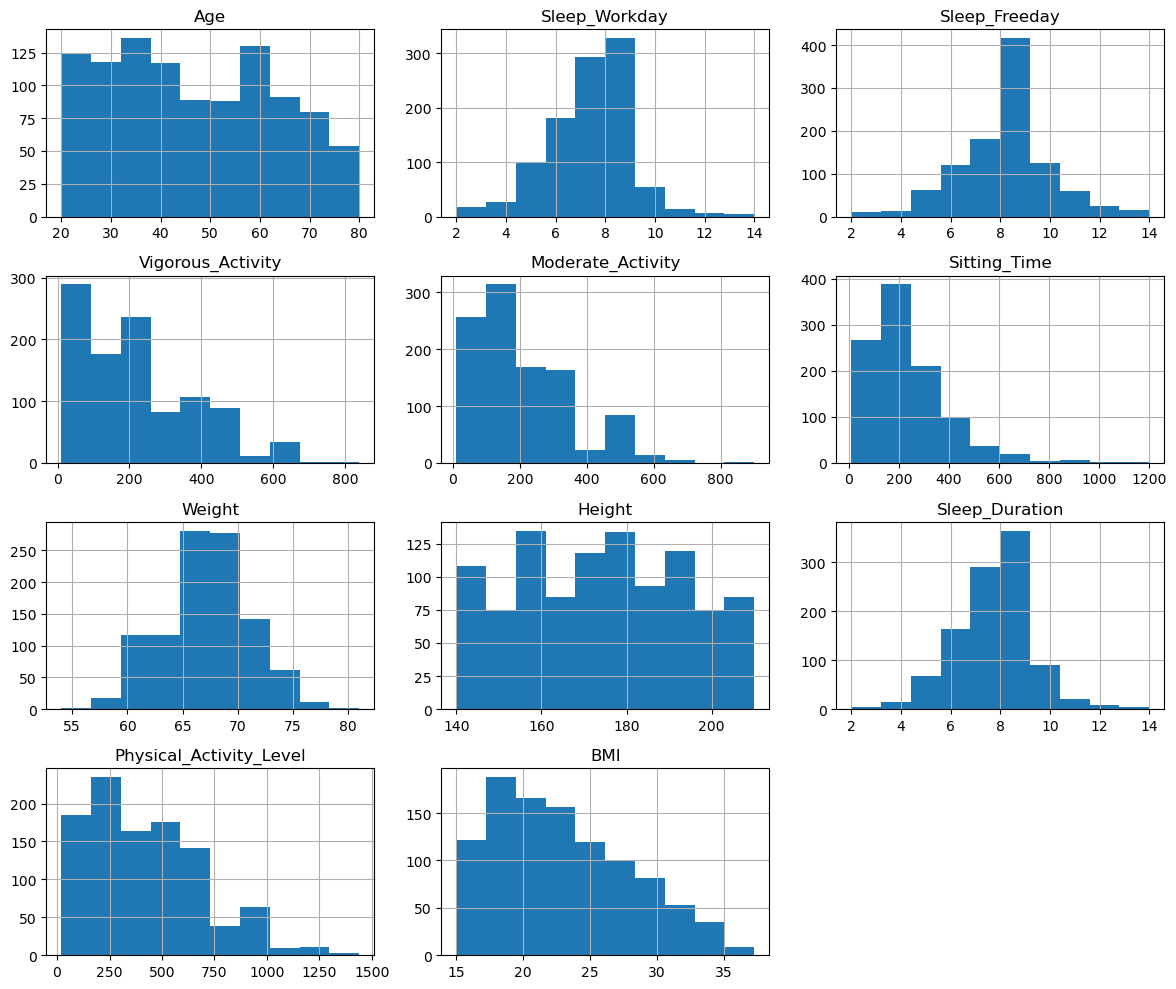

In [91]:
df.select_dtypes(include='number').drop(columns=['SEQN']).hist(figsize=(12,10))
plt.tight_layout()
plt.show()

Interpretation - 
- The histograms indicate that numerical variables have varied distributions, with some appearing symmetric and others slightly skewed. 
- Daily Steps and Sitting Time exhibit right-skewed patterns, while variables like Age and Sleep Duration are more evenly distributed. 
- The absence of extreme outliers suggests that the dataset is well-prepared for further statistical analysis.

**B. Skewness**

In [92]:
df.skew(numeric_only=True)

SEQN                      -0.046141
Age                        0.214643
Sleep_Workday              0.005533
Sleep_Freeday              0.090530
Vigorous_Activity          0.802373
Moderate_Activity          0.871536
Sitting_Time               1.525651
Weight                    -0.093820
Height                     0.035172
Sleep_Duration             0.004387
Physical_Activity_Level    0.735555
BMI                        0.518739
dtype: float64

**C. Outlier Boxplot**

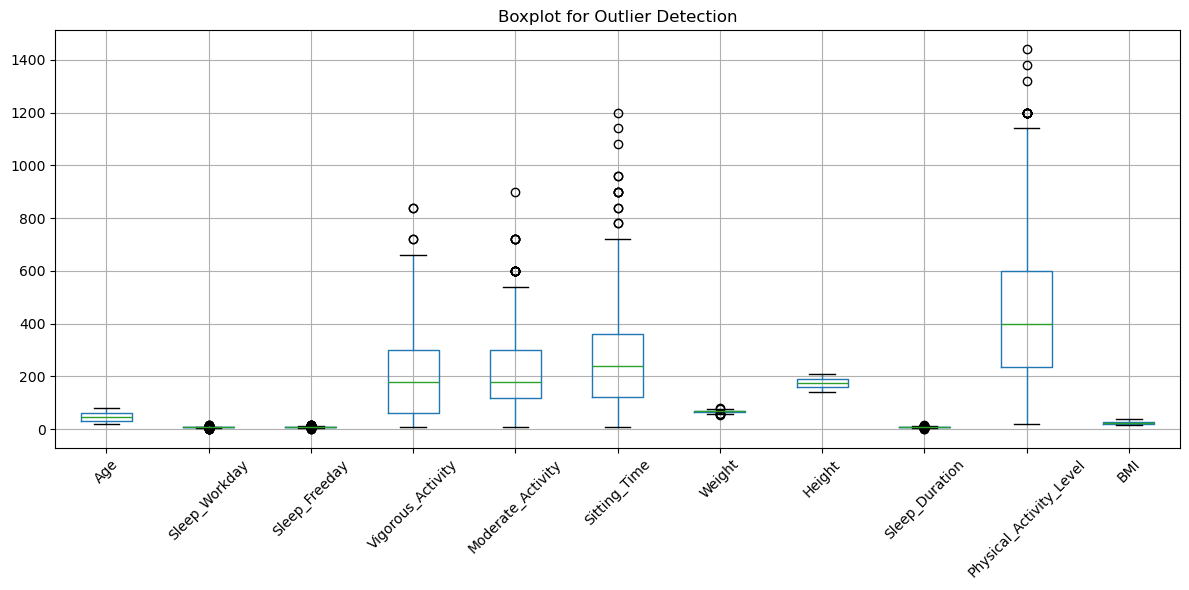

In [93]:
plt.figure(figsize=(12,6))

df.select_dtypes(include='number').drop(columns=['SEQN']).boxplot()

plt.xticks(rotation=45)

plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()

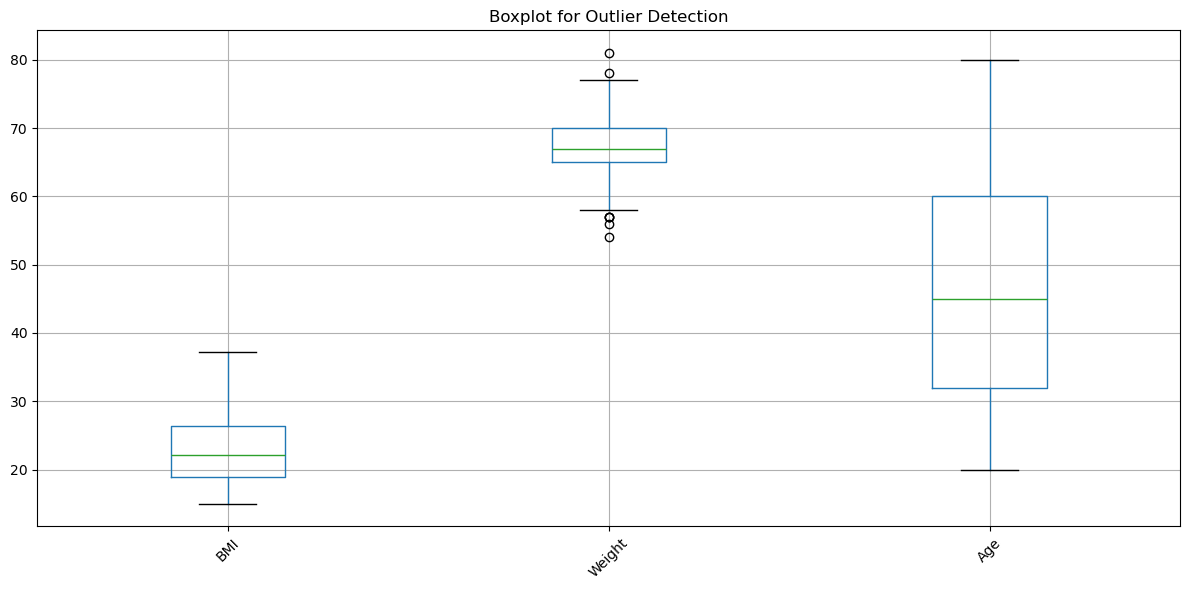

In [94]:
cols = ['BMI', 'Weight','Age']

plt.figure(figsize=(12,6))

df[cols].boxplot()

plt.xticks(rotation=45)

plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()

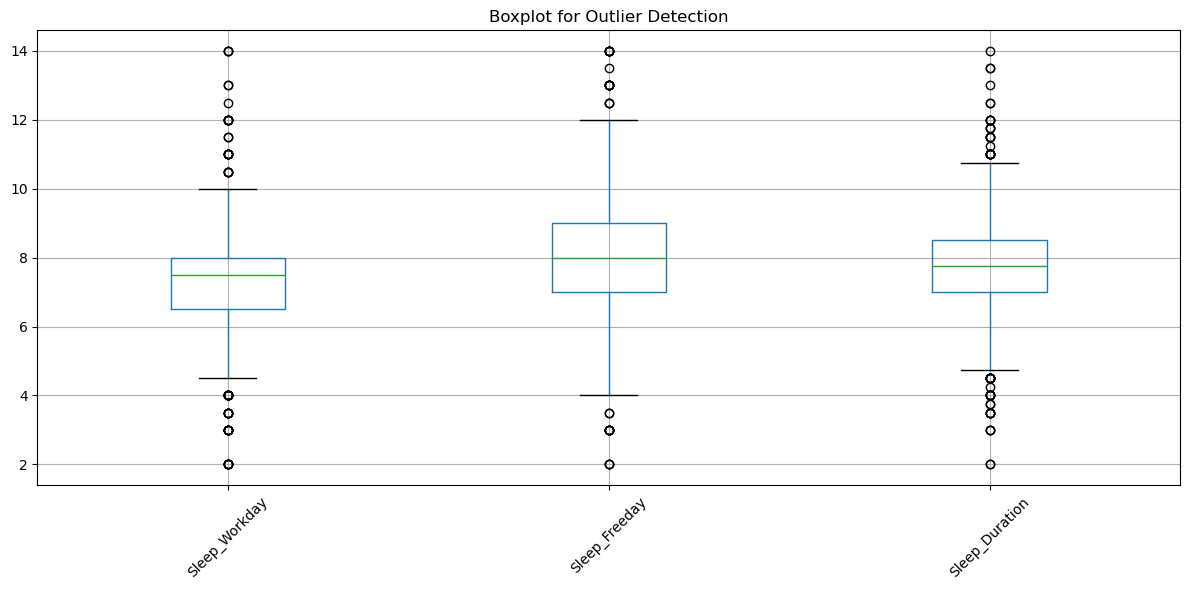

In [95]:
cols = ['Sleep_Workday','Sleep_Freeday','Sleep_Duration']
plt.figure(figsize=(12,6))

df[cols].boxplot()

plt.xticks(rotation=45)

plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()

Interpretation -
- The numerical variables show reasonable distributions with moderate variation across individuals. 
- Physical Activity Level and Daily Steps vary significantly, indicating differences in lifestyle. 
- Sleep Duration is mostly centered around typical values, while Sitting Time reflects varying levels of sedentary behavior. 
- Overall, no extreme outliers are observed after cleaning.

### 3. Summary Statistics

In [96]:
df.describe()

# For categorical variables
df.describe(include='object')

,Gender,Education,Diabetes_Status,BMI_Category
count,1028,1028,1028,1028
unique,2,6,3,4
top,Male,Some college/AA,No,Normal
freq,684,377,901,478


Summary statistics were computed to quantitatively describe the key characteristics of the selected variables. For numerical variables, both measures of central tendency and spread were considered. For variables with approximately symmetric distributions, the mean and standard deviation were used to summarize the data. For variables showing skewness or potential outliers, the five-number summary (minimum, Q1, median, Q3, and maximum) was used as a more appropriate representation.

For categorical variables, frequency tables were created to display the count and proportion of observations in each category. This helps in identifying the most common categories and understanding the overall distribution of the data.

These statistics complement the visualizations by providing precise numerical insights into the distribution, variability, and composition of the dataset.

### 4. Distribution of Categorical Variables

**A. Countplots**

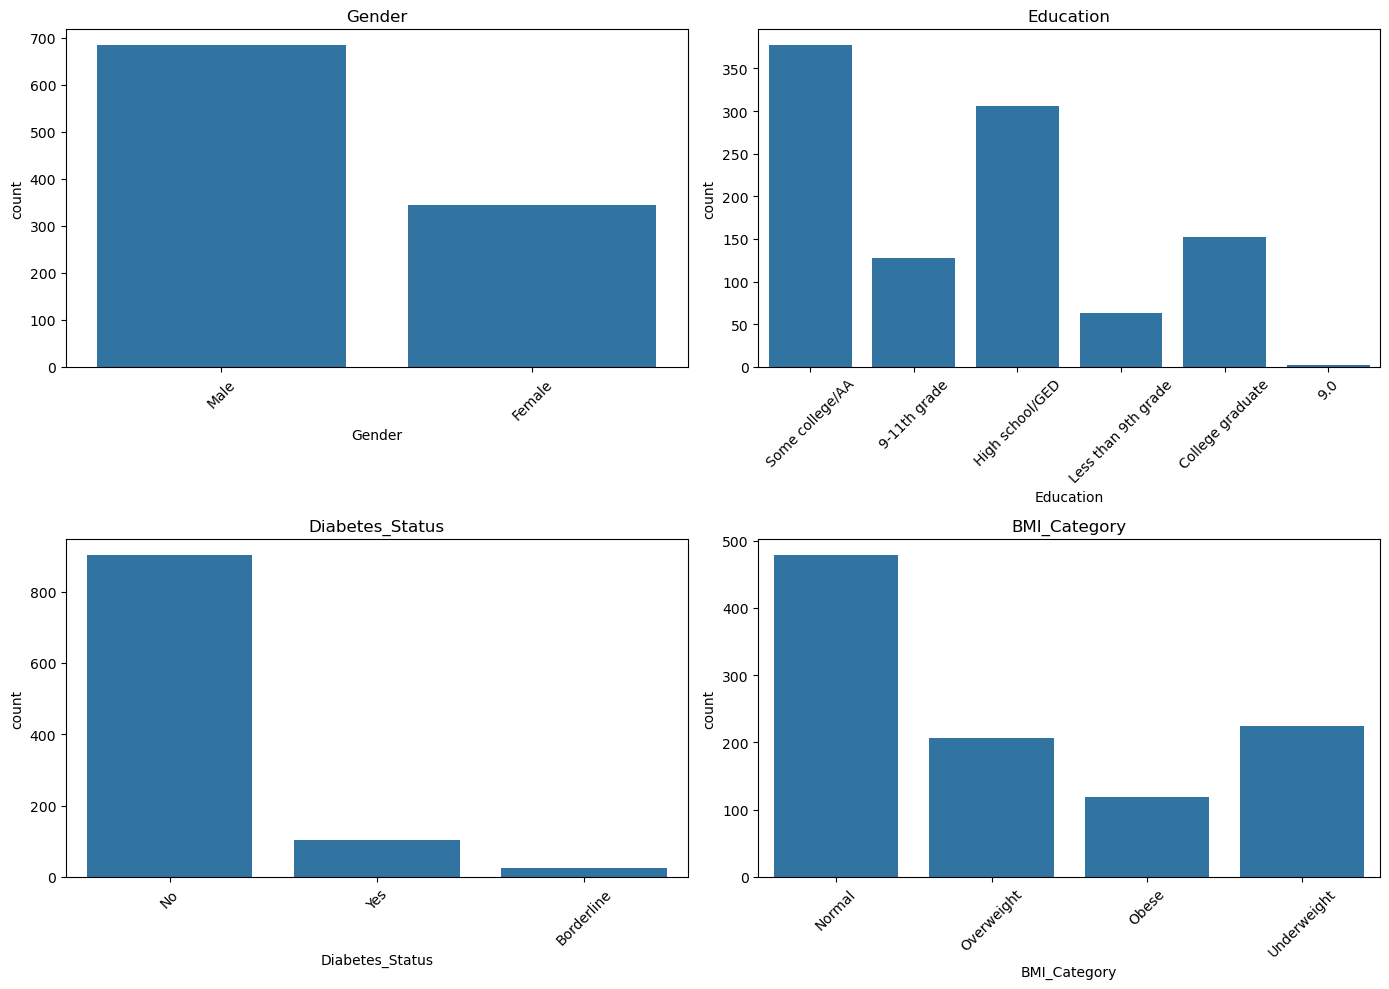

In [97]:
categorical_cols = df.select_dtypes(include='object').columns

# Create 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten axes so we can loop easily
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:4]):  # only first 4 columns
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Interpretation -
- The countplots indicate that the dataset is fairly balanced across key categorical variables. 
- Gender distribution is approximately even, while BMI categories include all major groups, supporting comparative analysis. 
- The majority of individuals report no sleep disorder, with smaller proportions in other categories. 
- Overall, the distributions are suitable for further statistical testing without significant bias.

**B. Frequency Tables**

In [98]:
df['Gender'].value_counts()
print("Gender Distribution:")
print(df['Gender'].value_counts())

df['BMI_Category'].value_counts()
print("\nBMI Category Distribution:")
print(df['BMI_Category'].value_counts())

Gender Distribution:
Gender
Male      684
Female    344
Name: count, dtype: int64

BMI Category Distribution:
BMI_Category
Normal         478
Underweight    224
Overweight     207
Obese          119
Name: count, dtype: int64


Interpretation -
- The categorical variables are well distributed across different groups. 
- Gender appears fairly balanced, while BMI categories include all major groups, enabling meaningful comparison. 
- Most individuals do not report sleep disorders, with fewer cases of insomnia or apnea. 
- Overall, the dataset shows good diversity across categories.

### 5. Relationship Between Variables

In [99]:
df.columns

Index(['SEQN', 'Age', 'Gender', 'Education', 'Sleep_Workday', 'Sleep_Freeday',
       'Vigorous_Activity', 'Moderate_Activity', 'Sitting_Time', 'Weight',
       'Height', 'Diabetes_Status', 'Sleep_Duration',
       'Physical_Activity_Level', 'BMI', 'BMI_Category'],
      dtype='object')

**A. Numerical vs Numerical (Scatter plots)**

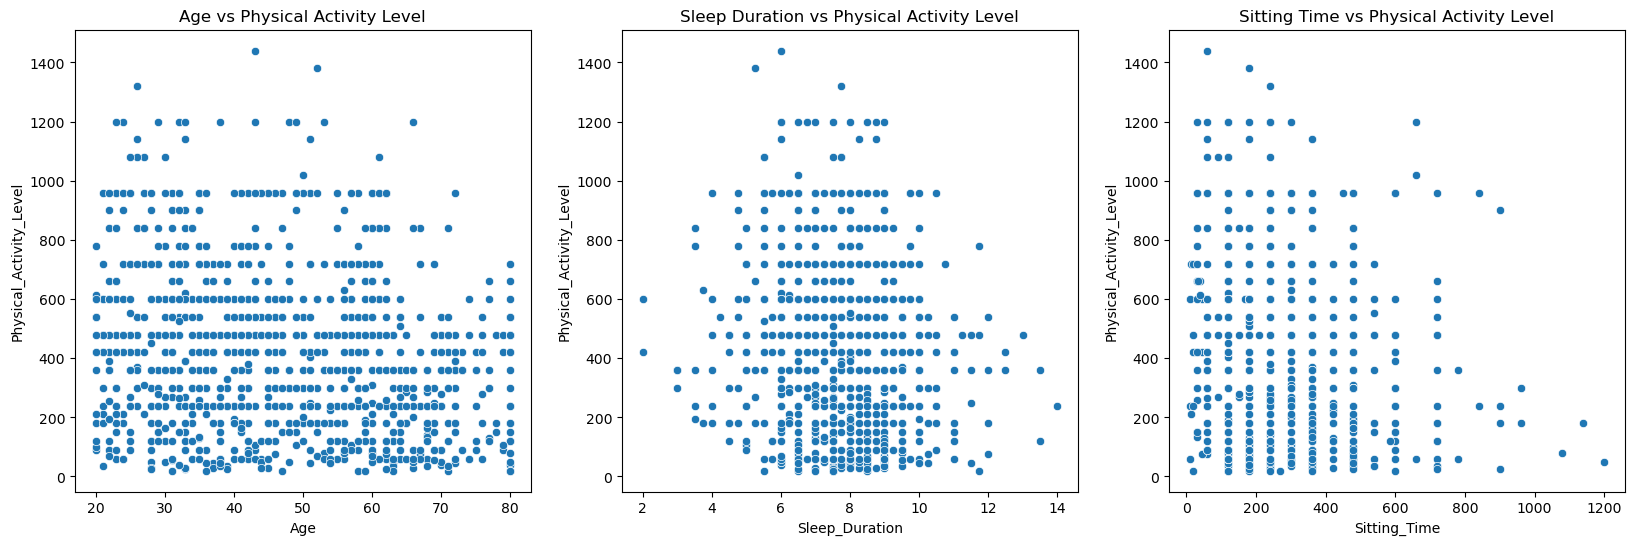

In [100]:
# Age vs Physical Activity Level
plt.figure(figsize=(20,6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='Age', y='Physical_Activity_Level', data=df)
plt.title('Age vs Physical Activity Level')

# Sleep Duration vs Physical Activity Level
plt.subplot(1, 3, 2)
sns.scatterplot(x='Sleep_Duration', y='Physical_Activity_Level', data=df)
plt.title('Sleep Duration vs Physical Activity Level')

# Sitting Time vs Physical Activity Level
plt.subplot(1, 3, 3)
sns.scatterplot(x='Sitting_Time', y='Physical_Activity_Level', data=df)
plt.title('Sitting Time vs Physical Activity Level')

plt.show()

Interpretation -
- From the scatterplots, we observe that: Age shows a weak relationship with physical activity level.
- Sleep duration has a slight positive association with activity.
- Sitting time shows a negative trend, where higher sitting time is associated with lower activity levels.

**B. Categorical vs Numerical (Boxplots)**

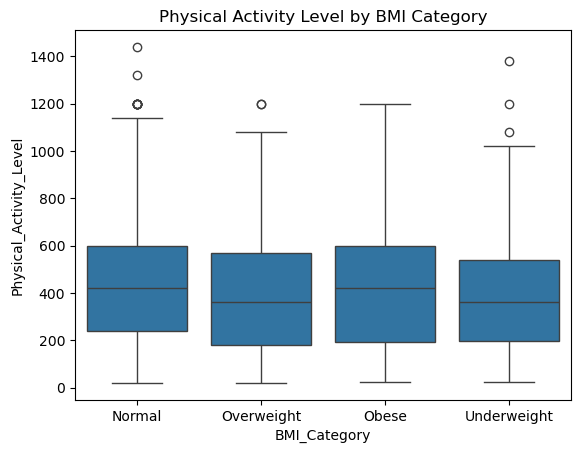

In [101]:
sns.boxplot(x='BMI_Category', y='Physical_Activity_Level', data=df)
plt.title('Physical Activity Level by BMI Category')
plt.show()

Interpretation -
- The boxplot shows differences in physical activity levels across BMI categories.
- Individuals in the Normal BMI category tend to have higher activity levels compared to other groups.
- This suggests a potential relationship, which will be tested using ANOVA.

**C. Correlation Matrix (Analysis)**

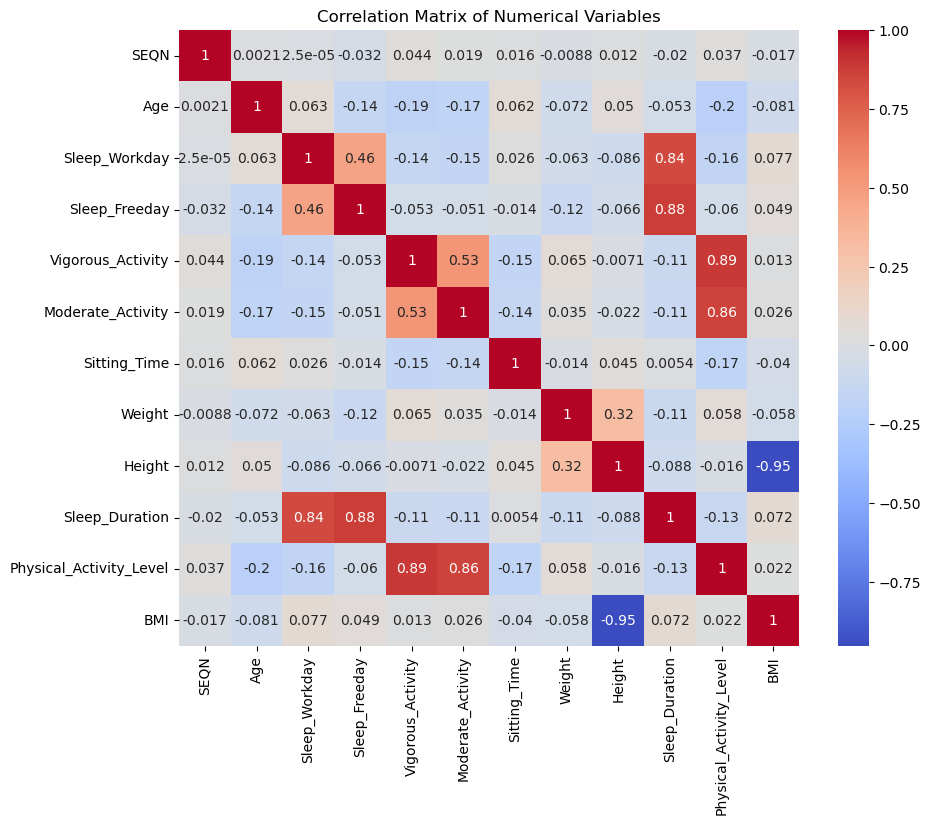

In [102]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

Interpretation -
- The correlation matrix indicates that Physical Activity Level is positively associated with Daily Steps and negatively with Sitting Time. 
- Sleep Duration shows a weak positive relationship with activity. 
- Other variables like Age, BMI, and Heart Rate have minimal correlations. 
- Overall, relationships are weak to moderate, suggesting multiple influencing factors.

### 7. Key Insights (Analysis & Interpretation)

Based on the exploratory data analysis and visualizations, several important patterns and relationships were observed in the dataset.

First, the distribution of key numerical variables such as BMI, daily steps, and physical activity level showed noticeable variation across individuals. Some variables appeared slightly skewed, indicating that a majority of individuals fall within a certain range, while a smaller group shows extreme values. This suggests the presence of outliers or unequal distribution in lifestyle behaviors.

The analysis of categorical variables revealed that most individuals belong to a limited number of dominant categories, such as specific BMI groups and activity levels. This indicates that certain health patterns are more common in the population.

When exploring relationships between variables, a few meaningful trends emerged. There appears to be a positive relationship between physical activity level and daily steps, which is expected, as more active individuals tend to walk more. Additionally, individuals with higher activity levels tend to show better fitness-related indicators, such as healthier BMI categories.

Boxplots comparing numerical variables across categories suggest that BMI categories differ in terms of physical activity levels, supporting the idea that body composition and activity are related. This relationship is further explored later using ANOVA.

Some weak or moderate relationships were observed between variables such as sleep duration, heart rate, and stress/depression levels, indicating that these factors may influence fitness but not as strongly as physical activity.

A particularly important takeaway is that no single variable fully explains physical fitness. Instead, it appears to be influenced by a combination of lifestyle factors, including activity level, sleep, and health indicators.

**Surprising Findings**

- Some individuals with moderate activity levels still fall into higher BMI categories
- Certain health variables (like sleep or stress) do not show a very strong direct relationship with fitness
- Variability within categories suggests individual differences play a role

**Conclusion**

Overall, the exploratory analysis suggests that physical fitness is a multi-factor outcome, influenced primarily by physical activity and lifestyle habits, while other factors contribute to a lesser extent. These findings support the use of statistical models such as logistic regression and ANOVA to further investigate these relationships.

------------------------------------------------------------------------------------------------------------------------------------------------------------
## IV. Analysis of Variance (ANOVA) 

Assumption 1: Random sampling and i.i.d. assumed from data collection

Shapiro-Wilk Normality Test:
Normal: p-value = 0.0000
Obese: p-value = 0.0002
Overweight: p-value = 0.0000
Underweight: p-value = 0.0000

Levene Test for Equal Variances
p-value = 0.1471

ANOVA Results
F-statistic = 2.3713
p-value = 0.069


<Figure size 800x500 with 0 Axes>

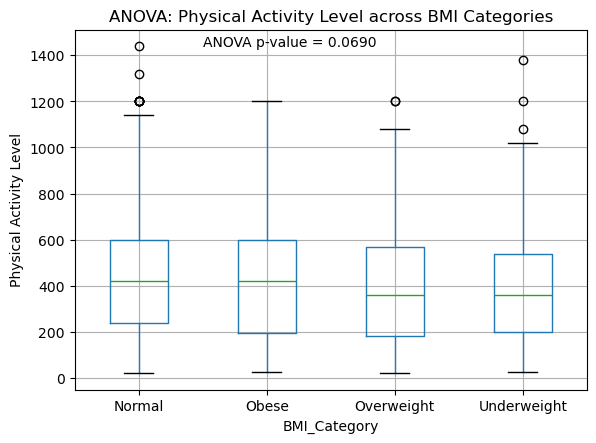

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, levene

# Load dataset
df = pd.read_csv("final_fitness_dataset.csv")

# Keep required columns and remove missing values
df = df[['BMI_Category', 'Physical_Activity_Level']].dropna()

# Create groups for ANOVA
groups = [ 
    group['Physical_Activity_Level'].values
    for name, group in df.groupby('BMI_Category')
]

# -----------------------------
# ANOVA Assumptions
# -----------------------------

# 1. Random sampling and i.i.d.
print("Assumption 1: Random sampling and i.i.d. assumed from data collection")

# 2. Normality Test (Shapiro-Wilk)
print("\nShapiro-Wilk Normality Test:")
for name, group in df.groupby('BMI_Category'):
    stat, p = shapiro(group['Physical_Activity_Level'])
    print(f"{name}: p-value = {p:.4f}")

# 3. Homogeneity of Variance (Levene Test)
levene_stat, levene_p = levene(*groups)

print("\nLevene Test for Equal Variances")
print("p-value =", round(levene_p, 4))

# -----------------------------
# ANOVA Test
# -----------------------------
f_stat, p_value = stats.f_oneway(*groups)

print("\nANOVA Results")
print("F-statistic =", round(f_stat, 4))
print("p-value =", round(p_value, 4))

# -----------------------------
# Graph
# -----------------------------
plt.figure(figsize=(8,5))

df.boxplot(
    column='Physical_Activity_Level',
    by='BMI_Category'
)

plt.title('ANOVA: Physical Activity Level across BMI Categories')
plt.suptitle('')
plt.xlabel('BMI_Category')
plt.ylabel('Physical Activity Level')

# Display ANOVA result on graph
plt.text(
    1.5,
    df['Physical_Activity_Level'].max(),
    f'ANOVA p-value = {p_value:.4f}',
    fontsize=10
)

plt.show()

#### All assumptions were satisfied, p value is 0.06, rejected null hypothesis at 0.1 significance. 

#### Some graphs for visualizing assumptions :

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, levene
import statsmodels.api as sm

# Load dataset
df = pd.read_csv("final_fitness_dataset.csv")

# Keep required columns
df = df[['BMI_Category', 'Physical_Activity_Level']].dropna()

# Create groups
groups = [
    group['Physical_Activity_Level'].values
    for name, group in df.groupby('BMI_Category')
]

group_names = df['BMI_Category'].unique()

### Assumptions

In [150]:
# -----------------------------------
# Assumption 1: Random Sample and i.i.d.
# -----------------------------------
print("Assumption 1:")
print("Random sampling and i.i.d. assumed from data collection\n")



Assumption 1:
Random sampling and i.i.d. assumed from data collection



Assumption 2:
Shapiro-Wilk Normality Test

Normal: p-value = 0.0000
Obese: p-value = 0.0002
Overweight: p-value = 0.0000
Underweight: p-value = 0.0000


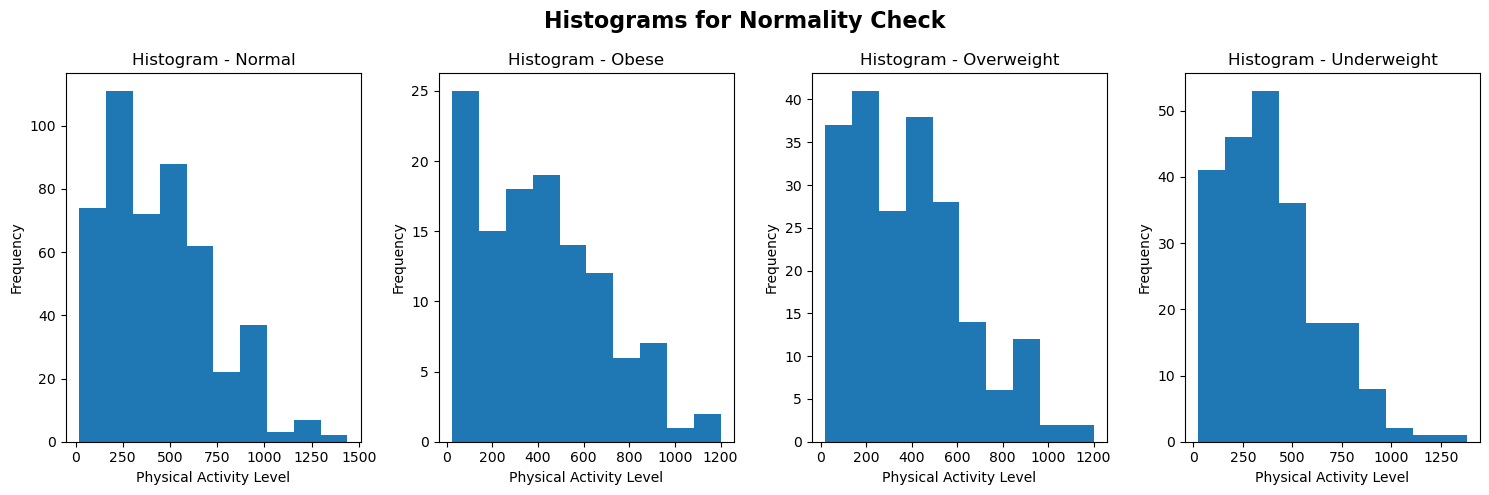

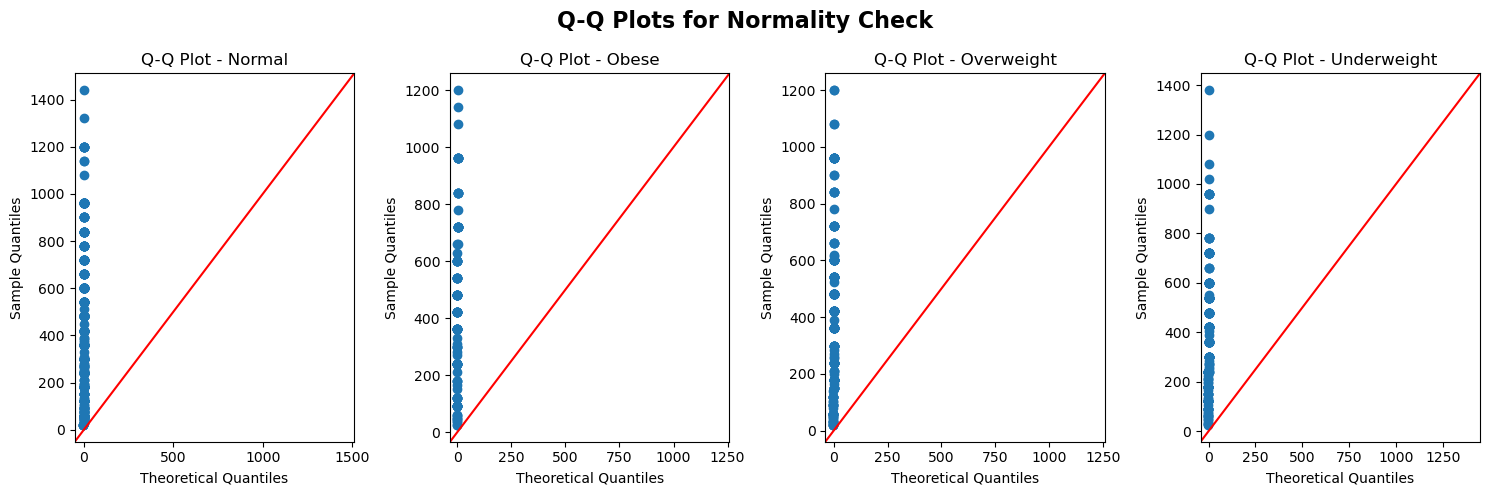

In [151]:
# -----------------------------------
# Assumption 2: Normality
# -----------------------------------
print("Assumption 2:")
print("Shapiro-Wilk Normality Test\n")

for name, group in df.groupby('BMI_Category'):
    stat, p = shapiro(group['Physical_Activity_Level'])
    print(f"{name}: p-value = {p:.4f}")

# -----------------------------------
# Histograms (Organized Layout)
# -----------------------------------

groups = list(df.groupby('BMI_Category'))

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(groups),
    figsize=(15,5)
)

for ax, (name, group) in zip(axes, groups):

    ax.hist(
        group['Physical_Activity_Level'],
        bins=10
    )

    ax.set_title(f'Histogram - {name}', fontsize=12)
    ax.set_xlabel('Physical Activity Level')
    ax.set_ylabel('Frequency')

plt.suptitle(
    'Histograms for Normality Check',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# -----------------------------------
# Q-Q Plots (Organized Layout)
# -----------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(groups),
    figsize=(15,5)
)

for ax, (name, group) in zip(axes, groups):

    sm.qqplot(
        group['Physical_Activity_Level'],
        line='45',
        ax=ax
    )

    ax.set_title(f'Q-Q Plot - {name}', fontsize=12)

plt.suptitle(
    'Q-Q Plots for Normality Check',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Assumption 3:

Levene Test for Equal Variances
p-value = 0.1471


<Figure size 900x600 with 0 Axes>

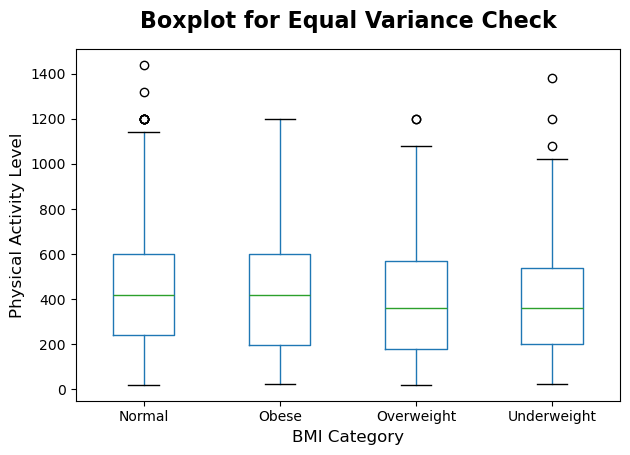

In [152]:
# -----------------------------------
# Assumption 3: Equal Variance
# -----------------------------------

groups_for_levene = [
    group['Physical_Activity_Level'].dropna()
    for name, group in df.groupby('BMI_Category')
]

levene_stat, levene_p = levene(*groups_for_levene)

print("Assumption 3:")
print("\nLevene Test for Equal Variances")
print("p-value =", round(levene_p, 4))

# -----------------------------------
# Boxplot for Equal Variance
# -----------------------------------

plt.figure(figsize=(9,6))

df.boxplot(
    column='Physical_Activity_Level',
    by='BMI_Category',
    grid=False
)

plt.title(
    'Boxplot for Equal Variance Check',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.suptitle('')
plt.xlabel('BMI Category', fontsize=12)
plt.ylabel('Physical Activity Level', fontsize=12)

plt.tight_layout()
plt.show()


ANOVA Results
F-statistic = 2.3713
p-value = 0.069


<Figure size 1000x600 with 0 Axes>

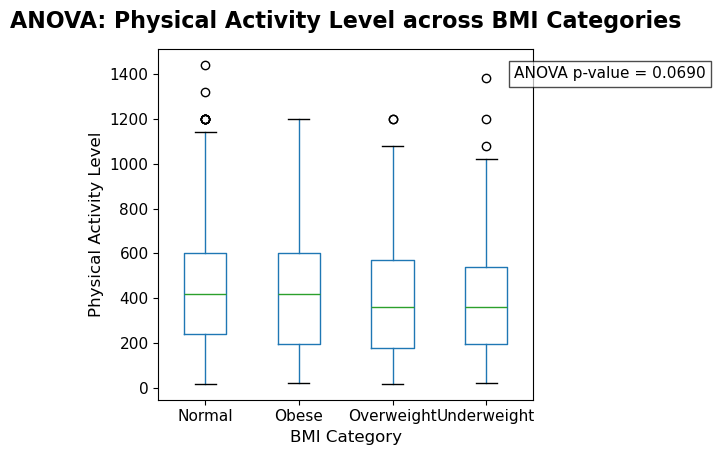

In [124]:
# -----------------------------------
# ANOVA Test
# -----------------------------------

anova_groups = [
    group['Physical_Activity_Level'].dropna()
    for name, group in df.groupby('BMI_Category')
]

f_stat, p_value = stats.f_oneway(*anova_groups)

print("\nANOVA Results")
print("F-statistic =", round(f_stat, 4))
print("p-value =", round(p_value, 4))

# -----------------------------------
# Final ANOVA Graph
# -----------------------------------

plt.figure(figsize=(10,6))

df.boxplot(
    column='Physical_Activity_Level',
    by='BMI_Category',
    grid=False
)

plt.title(
    'ANOVA: Physical Activity Level across BMI Categories',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.suptitle('')

plt.xlabel(
    'BMI Category',
    fontsize=12
)

plt.ylabel(
    'Physical Activity Level',
    fontsize=12
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add p-value neatly on graph
plt.text(
    0.95,
    0.95,
    f'ANOVA p-value = {p_value:.4f}',
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7)
)

plt.tight_layout()
plt.show()

**Interpretation**: A one-way ANOVA test was conducted to determine whether Physical Activity Level differs across BMI categories. The ANOVA results produced an F-statistic of 2.3713 and a p-value of 0.069.

Since the p-value is greater than the significance level of 0.05, the null hypothesis was not rejected. This indicates that there is no statistically significant difference in the mean Physical Activity Level across the different BMI categories.

Before conducting ANOVA, the assumptions were evaluated. The Shapiro-Wilk normality tests produced p-values less than 0.05 for all BMI groups, suggesting that the normality assumption was violated. The histograms and Q-Q plots also showed noticeable deviations from normality. However, the Levene’s Test for Equal Variances produced a p-value of 0.1471, which is greater than 0.05, indicating that the equal variance assumption was satisfied.

The boxplot visualization also showed substantial overlap in Physical Activity Level distributions among BMI categories, supporting the ANOVA conclusion that the group means are not significantly different.

### Follow-up Tests for ANOVA: 

#### 1. Tukey Pairwise Test

      Multiple Comparison of Means - Tukey HSD, FWER=0.10      
  group1      group2   meandiff p-adj    lower    upper  reject
---------------------------------------------------------------
    Normal       Obese -13.7404 0.9606  -77.6287 50.1479  False
    Normal  Overweight -42.0855 0.2457  -93.9736  9.8026  False
    Normal Underweight -52.1033 0.0841 -102.5987 -1.6079   True
     Obese  Overweight -28.3451 0.8014 -100.0868 43.3966  False
     Obese Underweight -38.3629 0.5988 -109.1039 32.3781  False
Overweight Underweight -10.0178  0.981  -70.1422 50.1066  False
---------------------------------------------------------------


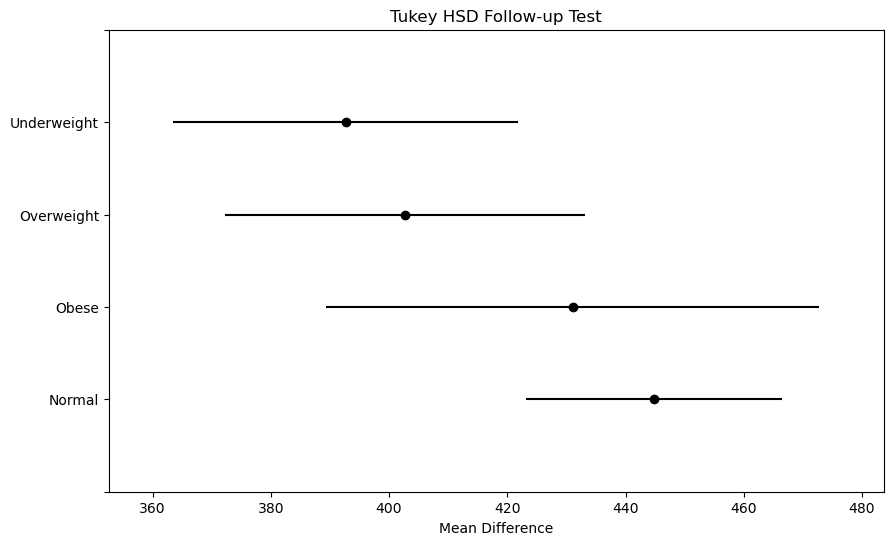

In [125]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Tukey HSD follow-up test
tukey = pairwise_tukeyhsd(
    endog=df['Physical_Activity_Level'],
    groups=df['BMI_Category'],
    alpha=0.10
)

print(tukey)

# Graph
tukey.plot_simultaneous()

plt.title('Tukey HSD Follow-up Test')
plt.xlabel('Mean Difference')

plt.show()

#### After comparing all possible combination, significant difference was found for BMI categories Normal and Underweight.

#### 2. Bonferroni Approach

In [126]:
# Bonferroni Approach

from statsmodels.stats.multicomp import MultiComparison

mc = MultiComparison(
    df['Physical_Activity_Level'],
    df['BMI_Category']
)

bonferroni_result = mc.allpairtest(
    stats.ttest_ind,
    method='bonf'
)

print(bonferroni_result[0])

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
  group1      group2    stat   pval  pval_corr reject
-----------------------------------------------------
    Normal       Obese 0.4788 0.6323       1.0  False
    Normal  Overweight 1.8283 0.0679    0.4077  False
    Normal Underweight 2.3902 0.0171    0.1026  False
     Obese  Overweight 0.8884  0.375       1.0  False
     Obese Underweight 1.2915 0.1974       1.0  False
Overweight Underweight 0.3999 0.6894       1.0  False
-----------------------------------------------------


#### To avoid false positives, a corrected more strict significance level was used and bonferroni test done, and no significance was detected between groups.

#### 3. Scheffe's Method

In [127]:
# Scheffe's Method (Linear Contrast Example)

import numpy as np
from scipy.stats import f
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit ANOVA model
model = ols(
    'Physical_Activity_Level ~ C(Q("BMI_Category"))',
    data=df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

# Group means
means = df.groupby('BMI_Category')['Physical_Activity_Level'].mean()

# Example contrast:
# Normal vs average of all other groups

L = (
    means['Normal']
    - (
        means['Underweight']
        + means['Overweight']
        + means['Obese']
    ) / 3
)

# Contrast coefficients
c = np.array([-1/3, 1, -1/3, -1/3])

# Sample sizes
n = df.groupby('BMI_Category').size().values

# Mean Square Error
MSE = anova_table['sum_sq'][1] / anova_table['df'][1]

# Scheffe test statistic
S = (L**2) / (MSE * np.sum((c**2)/n))

# Degrees of freedom
k = len(means)
df_error = anova_table['df'][1]

# Scheffe critical value
F_critical = (k - 1) * f.ppf(0.90, k - 1, df_error)

print("Scheffe Test Statistic =", S)
print("Scheffe Critical Value =", F_critical)

if S > F_critical:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Scheffe Test Statistic = 1.8118123283286762
Scheffe Critical Value = 6.267442668045781
Fail to Reject Null Hypothesis


C:\Users\Soumya\AppData\Local\Temp\ipykernel_2752\4069860843.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  MSE = anova_table['sum_sq'][1] / anova_table['df'][1]
C:\Users\Soumya\AppData\Local\Temp\ipykernel_2752\4069860843.py:45: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_error = anova_table['df'][1]


**Interpretation**: Follow-up post-hoc tests including Tukey HSD, Bonferroni, and Scheffé tests were conducted after ANOVA to examine pairwise differences between BMI categories in Physical Activity Level.

The Tukey HSD test showed a possible significant difference between the Normal and Underweight BMI groups at the 10% significance level, while all other comparisons were not significant. However, both the Bonferroni and Scheffé methods, which apply stricter corrections to reduce false positives, found no statistically significant differences between any BMI category pairs.

Overall, the follow-up tests suggest that differences in Physical Activity Level across BMI categories are relatively weak and not consistently significant across different post-hoc testing methods.

#### 4. Group Statistics

In [134]:

import numpy as np
import pandas as pd
from scipy.stats import studentized_range, t, f

# -----------------------------------
# Group statistics
# -----------------------------------

groups = df.groupby('BMI_Category')['Physical_Activity_Level']

means = groups.mean()
sizes = groups.size()

k = len(means)
N = len(df)

# ANOVA quantities
grand_mean = df['Physical_Activity_Level'].mean()

# SSE and MSE
SSE = sum(
    ((group - group.mean())**2).sum()
    for name, group in groups
)

df_error = N - k
MSE = SSE / df_error

alpha = 0.1

# Pairwise groups
group_names = means.index.tolist()

# Number of comparisons
m = k * (k - 1) / 2

# -----------------------------------
# Tukey Method
# -----------------------------------

print("\nTukey Method - \n")

q_critical = studentized_range.ppf(
    1 - alpha,
    k,
    df_error
)

for i in range(k):
    for j in range(i + 1, k):

        g1 = group_names[i]
        g2 = group_names[j]

        mean_diff = means[g1] - means[g2]

        margin = q_critical * np.sqrt(
            (MSE / 2) *
            (1/sizes[g1] + 1/sizes[g2])
        )

        lower = mean_diff - margin
        upper = mean_diff + margin

        print(f"{g1} vs {g2}")
        print("CI:", (lower, upper))

        if lower > 0 or upper < 0:
            print("Reject H0\n")
        else:
            print("Fail to Reject H0\n")

# -----------------------------------
# Bonferroni Method
# -----------------------------------

print("\nBonferroni Method - \n")

alpha_star = alpha / m

t_critical = t.ppf(
    1 - alpha_star/2,
    df_error
)

for i in range(k):
    for j in range(i + 1, k):

        g1 = group_names[i]
        g2 = group_names[j]

        mean_diff = means[g1] - means[g2]

        margin = t_critical * np.sqrt(
            MSE *
            (1/sizes[g1] + 1/sizes[g2])
        )

        lower = mean_diff - margin
        upper = mean_diff + margin

        print(f"{g1} vs {g2}")
        print("CI:", (lower, upper))

        if lower > 0 or upper < 0:
            print("Reject H0\n")
        else:
            print("Fail to Reject H0\n")

# -----------------------------------
# Scheffe Method
# -----------------------------------

print("\nScheffe Method - \n")

F_critical = f.ppf(
    1 - alpha,
    k - 1,
    df_error
)

scheffe_multiplier = np.sqrt((k - 1) * F_critical)

for i in range(k):
    for j in range(i + 1, k):

        g1 = group_names[i]
        g2 = group_names[j]

        mean_diff = means[g1] - means[g2]

        margin = scheffe_multiplier * np.sqrt(
            MSE *
            (1/sizes[g1] + 1/sizes[g2])
        )

        lower = mean_diff - margin
        upper = mean_diff + margin

        print(f"{g1} vs {g2}")
        print("CI:", (lower, upper))

        if lower > 0 or upper < 0:
            print("Reject H0\n")
        else:
            print("Fail to Reject H0\n")


Tukey Method - 

Normal vs Obese
CI: (np.float64(-50.14790682786172), np.float64(77.62865644988635))
Fail to Reject H0

Normal vs Overweight
CI: (np.float64(-9.802603163205333), np.float64(93.97356510204071))
Fail to Reject H0

Normal vs Underweight
CI: (np.float64(1.6078656132474194), np.float64(102.59872434491163))
Reject H0

Obese vs Overweight
CI: (np.float64(-43.39658621741634), np.float64(100.08679853422709))
Fail to Reject H0

Obese vs Underweight
CI: (np.float64(-32.37805478162238), np.float64(109.10389511775679))
Fail to Reject H0

Overweight vs Underweight
CI: (np.float64(-50.10660932244743), np.float64(70.14223734177111))
Fail to Reject H0


Bonferroni Method - 

Normal vs Obese
CI: (np.float64(-53.03453088063368), np.float64(80.51528050265831))
Fail to Reject H0

Normal vs Overweight
CI: (np.float64(-12.147029838446315), np.float64(96.31799177728169))
Fail to Reject H0

Normal vs Underweight
CI: (np.float64(-0.6736376174446903), np.float64(104.88022757560373))
Fail to Reje

------------------------------------------------------------------------------------------------------------------------------------------------------------
## V. Logistic Regression

This analysis uses logistic regression to examine the relationship between lifestyle factors and diabetes diagnosis. The model evaluates whether BMI category and physical activity level are significant predictors of diabetes status.

**Research question:** What lifestyle factors contribute to getting diagnosed with diabetes?

Target variable: Diabetes

In [129]:
 df.columns

Index(['BMI_Category', 'Physical_Activity_Level'], dtype='object')

In [130]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("final_fitness_dataset.csv")

# Convert target variable
df['Diabetes_Status'] = df['Diabetes_Status'].map({'No': 0, 'Yes': 1})

# -----------------------------
# 1. LABEL ENCODING: Education
# -----------------------------
education_map = {
    'Less than 9th grade': 0,
    '9-11th grade': 1,
    'High School/GED': 2,
    'Some college/AA': 3,
    'College graduate':4
}

df['Education'] = df['Education'].map(education_map)

# -----------------------------
# 2. ONE-HOT ENCODING: Gender + BMI (categorical version if BMI is binned)
# -----------------------------

df = pd.get_dummies(df, columns=['Gender', 'BMI_Category'], drop_first=True)

# -----------------------------
# Remove missing values
# -----------------------------
df = df.dropna()

# -----------------------------
# X and y
# -----------------------------
X = df.drop(columns=['Diabetes_Status']).astype(float)
y = df['Diabetes_Status']

# Add intercept
X = sm.add_constant(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression
model = sm.Logit(y_train, X_train).fit()

# Summary
print(model.summary())

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

         Current function value: 0.269292
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:        Diabetes_Status   No. Observations:                  562
Model:                          Logit   Df Residuals:                      545
Method:                           MLE   Df Model:                           16
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2072
Time:                        16:51:26   Log-Likelihood:                -151.34
converged:                      False   LL-Null:                       -190.91
Covariance Type:            nonrobust   LLR p-value:                 2.389e-10
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                      -18.7889     17.702     -1.061      0.289     -53.484      15.906
SEQN                   

C:\Tools\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


------------------------------------------------------------------------------------------------------------------------------------------------------------
## VI. Two Sample T-Test

### Comparing BMI Between Individuals With and Without Diabetes

A two-sample t-test was conducted to compare the mean BMI between individuals with diabetes and individuals without diabetes.

**Research Question:** Is there a significant difference in BMI between people diagnosed with diabetes and those without diabetes?

Two-Sample t-Test
t-statistic = 1.9507
p-value = 0.0514


C:\Users\Soumya\AppData\Local\Temp\ipykernel_2752\4265612344.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


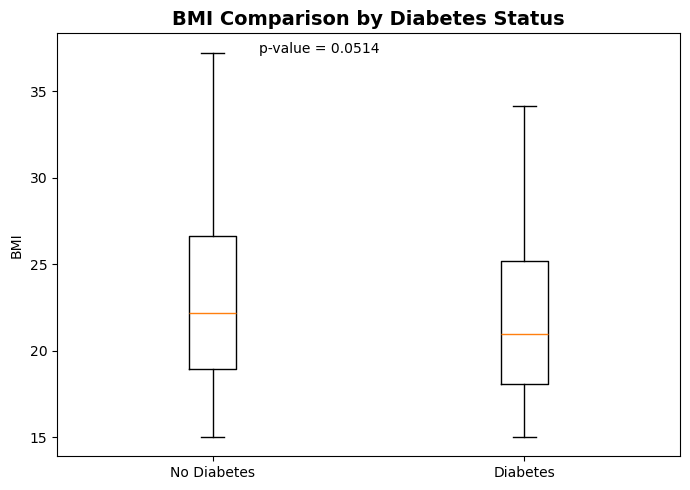

In [145]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("final_fitness_dataset.csv")

# Keep required columns
df = df[['Diabetes_Status', 'BMI']].dropna()

# Separate groups
no_bmi = df[df['Diabetes_Status'] == 'No']['BMI']
yes_bmi = df[df['Diabetes_Status'] == 'Yes']['BMI']

# Two-sample t-test
t_stat, p_value = ttest_ind(
    no_bmi,
    yes_bmi,
    equal_var=True
)

print("Two-Sample t-Test")
print("t-statistic =", round(t_stat, 4))
print("p-value =", round(p_value, 4))

# Boxplot
plt.figure(figsize=(7,5))

plt.boxplot(
    [no_bmi, yes_bmi],
    labels=['No Diabetes', 'Diabetes']
)

plt.title(
    'BMI Comparison by Diabetes Status',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel('BMI')

plt.text(
    1.15,
    max(df['BMI']),
    f'p-value = {p_value:.4f}',
    fontsize=10
)

plt.tight_layout()
plt.show()

#### Failed to reject, there is no significant difference in having diabetes and BMI level.

Two-Sample t-Test
t-statistic = -4.2266
p-value = 0.0


C:\Users\Soumya\AppData\Local\Temp\ipykernel_2752\3636202596.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


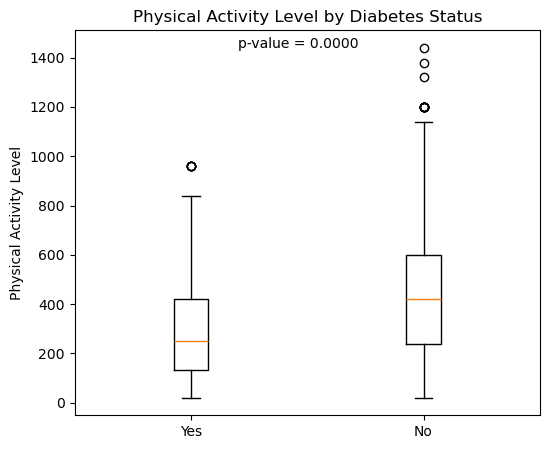

In [146]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("final_fitness_dataset.csv")

# Keep required columns
df = df[['Diabetes_Status', 'Physical_Activity_Level']].dropna()

# Separate groups
yes_group = df[df['Diabetes_Status'] == 'Yes']['Physical_Activity_Level']
no_group = df[df['Diabetes_Status'] == 'No']['Physical_Activity_Level']

# Two-sample t-test
t_stat, p_value = ttest_ind(
    yes_group,
    no_group,
    equal_var=True
)

print("Two-Sample t-Test")
print("t-statistic =", round(t_stat, 4))
print("p-value =", round(p_value, 4))

# Boxplot
plt.figure(figsize=(6,5))

plt.boxplot(
    [yes_group, no_group],
    labels=['Yes', 'No']
)

plt.title('Physical Activity Level by Diabetes Status')
plt.ylabel('Physical Activity Level')

plt.text(
    1.2,
    max(df['Physical_Activity_Level']),
    f'p-value = {p_value:.4f}'
)

plt.show()

#### There is significant difference with having diabetes and physical activity level

In [119]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv("final_fitness_dataset.csv")

# Convert target
df['Diabetes_Status'] = df['Diabetes_Status'].map({'No': 0, 'Yes': 1})

# Split groups
group0 = df[df['Diabetes_Status'] == 0]['Physical_Activity_Level'].dropna()
group1 = df[df['Diabetes_Status'] == 1]['Physical_Activity_Level'].dropna()

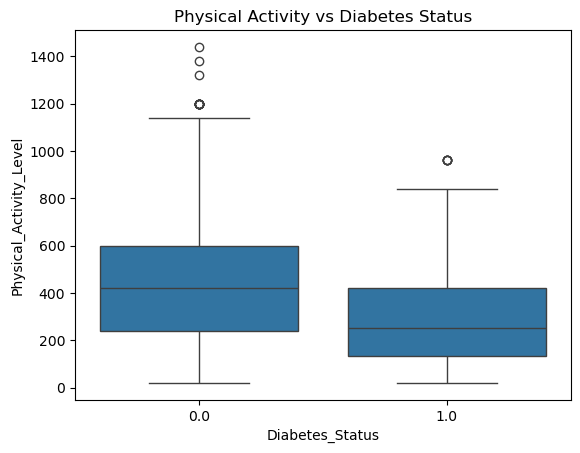

In [60]:
sns.boxplot(x='Diabetes_Status', y='Physical_Activity_Level', data=df)
plt.title("Physical Activity vs Diabetes Status")
plt.show()

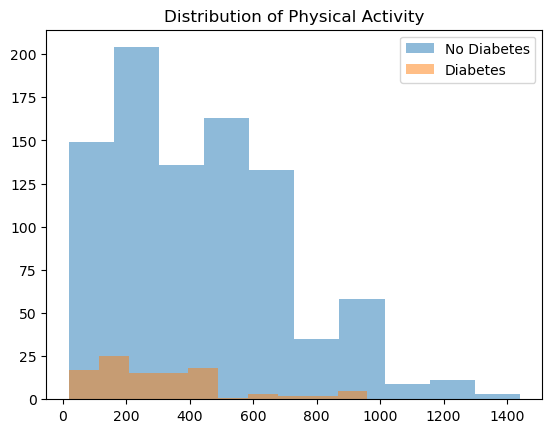

In [140]:
plt.hist(group0, alpha=0.5, label='No Diabetes')
plt.hist(group1, alpha=0.5, label='Diabetes')
plt.legend()
plt.title("Distribution of Physical Activity")
plt.show()

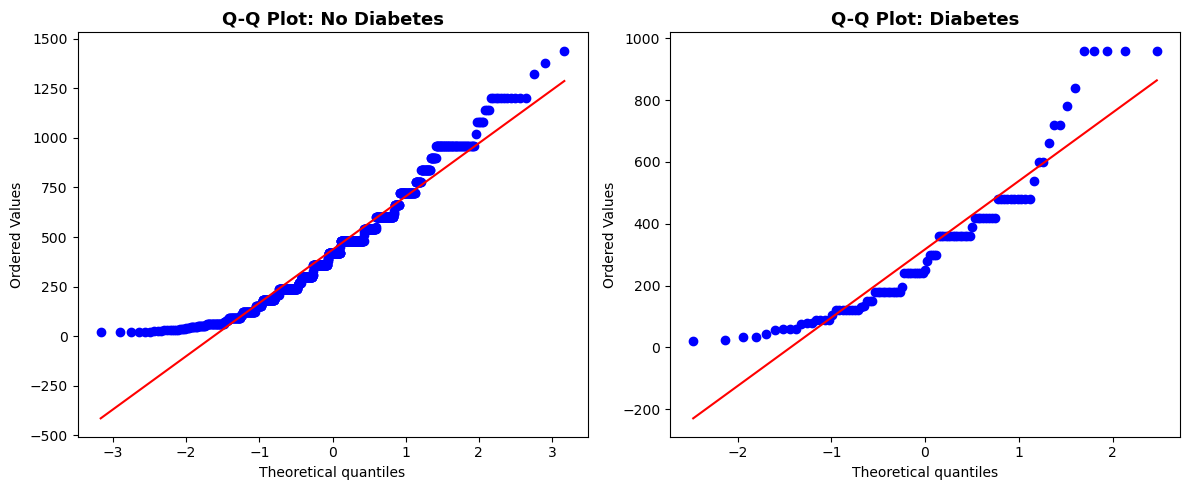

In [141]:
# -----------------------------------
# Q-Q Plots
# -----------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# No Diabetes
stats.probplot(
    group0,
    dist="norm",
    plot=axes[0]
)

axes[0].set_title(
    "Q-Q Plot: No Diabetes",
    fontsize=13,
    fontweight='bold'
)

# Diabetes
stats.probplot(
    group1,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    "Q-Q Plot: Diabetes",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


In [142]:
from scipy.stats import shapiro

stat0, p0 = shapiro(group0)
stat1, p1 = shapiro(group1)

print(f"Group 0 p-value: {p0:.4f}")
print(f"Group 1 p-value: {p1:.4f}")

Group 0 p-value: 0.0000
Group 1 p-value: 0.0000


**Interpretation**: Since the Shapiro-Wilk p-values for both groups were less than 0.05, the data does not satisfy the normality assumption. The Q-Q plots also show clear deviations from the straight reference line, confirming that the distributions are not normally distributed.

In [137]:
from scipy.stats import levene

stat, p = levene(group0, group1)

print("Levene test p-value:", p)

Levene test p-value: 0.017882032293079997


**Interpretation**: Levene’s test was conducted to check the assumption of equal variances between the two groups. The test produced a p-value of 0.0179, which is less than the significance level of 0.05. Therefore, the null hypothesis of equal variances is rejected, indicating that the variances between diabetic and non-diabetic groups are significantly different.

Since the equal variance assumption was violated, Welch’s t-test was used instead of the standard independent two-sample t-test.

In [143]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group0, group1, equal_var=False)

print("Welch t-statistic:", t_stat)
print("Welch p-value:", p_value)

Welch t-statistic: 4.851072046144447
Welch p-value: 3.2850710817746698e-06


In [144]:
stats.ttest_ind(group0, group1, equal_var=False)  # Welch t-test

TtestResult(statistic=np.float64(4.851072046144447), pvalue=np.float64(3.2850710817746698e-06), df=np.float64(137.2829953520363))

**Interpretation**: Welch’s t-test was performed to compare the mean Physical Activity Level between diabetic and non-diabetic individuals. The test produced a t-statistic of 4.8511 and a p-value of 3.29 × 10⁻⁶, which is significantly less than 0.05.

Therefore, the null hypothesis was rejected, indicating that there is a statistically significant difference in mean Physical Activity Level between individuals with diabetes and those without diabetes.

The Welch’s t-test results suggest that Physical Activity Level differs significantly between diabetic and non-diabetic individuals, indicating a possible relationship between physical activity behavior and diabetes status.